In [1]:
"""Design and develop a distributed application to find the coolest/hottest year from the available
weather data. Use weather data from the Internet and process it using MapReduce. """


import pandas as pd

df = pd.read_csv('mumbai_weather.csv')
df.head()

,time,tavg,tmin,tmax,prcp
0,01-01-1990,23.2,17.0,NaN,0.0
1,02-01-1990,22.2,16.5,29.9,0.0
2,03-01-1990,21.8,16.3,30.7,0.0
3,04-01-1990,25.4,17.9,31.8,0.0
4,05-01-1990,26.5,19.3,33.7,0.0


In [2]:
df['tavg'] = df['tavg'].fillna((df['tmin'] + df['tmax'])/2)
df.isnull().sum()

time       0
tavg      11
tmin    2454
tmax    1907
prcp    4681
dtype: int64

In [3]:
df['Year'] = df['time'].apply(lambda x: x.split('-')[2])

df.tail()

,time,tavg,tmin,tmax,prcp,Year
11889,21-07-2022,27.6,25.6,30.5,10.9,2022
11890,22-07-2022,28.3,26.0,30.5,3.0,2022
11891,23-07-2022,28.2,25.8,31.3,5.1,2022
11892,24-07-2022,28.1,25.6,30.4,7.1,2022
11893,25-07-2022,28.3,25.1,30.2,7.1,2022


In [4]:
df['tavg'] = df.groupby('Year')['tavg'].transform(lambda x: x.fillna(x.mean()))

In [5]:
df['tmin'] = df['tmin'].fillna(df['tavg'] - 5)
df['tmax'] = df['tmax'].fillna(df['tavg'] + 5)

df['prcp'] = df['prcp'].fillna(0)

In [6]:
df.isnull().sum()

time    0
tavg    0
tmin    0
tmax    0
prcp    0
Year    0
dtype: int64

In [7]:
df.shape

(11894, 6)

In [8]:
def mapper(df):
    result = []

    for _,row in df.iterrows():
        year = row['Year']
        tavg = row['tavg']
        result.append((year,tavg))

    return result

In [9]:
mapped_output = mapper(df)
mapped_output

[('1990', 23.2),
 ('1990', 22.2),
 ('1990', 21.8),
 ('1990', 25.4),
 ('1990', 26.5),
 ('1990', 25.1),
 ('1990', 26.0),
 ('1990', 26.6),
 ('1990', 25.1),
 ('1990', 26.8),
 ('1990', 25.6),
 ('1990', 24.3),
 ('1990', 22.4),
 ('1990', 25.4),
 ('1990', 23.7),
 ('1990', 24.0),
 ('1990', 24.8),
 ('1990', 23.8),
 ('1990', 25.5),
 ('1990', 25.2),
 ('1990', 25.4),
 ('1990', 25.8),
 ('1990', 26.4),
 ('1990', 26.1),
 ('1990', 25.5),
 ('1990', 25.9),
 ('1990', 25.2),
 ('1990', 24.1),
 ('1990', 23.8),
 ('1990', 24.2),
 ('1990', 24.3),
 ('1990', 24.2),
 ('1990', 23.2),
 ('1990', 24.8),
 ('1990', 23.8),
 ('1990', 24.0),
 ('1990', 26.0),
 ('1990', 27.1),
 ('1990', 27.0),
 ('1990', 26.5),
 ('1990', 28.2),
 ('1990', 28.1),
 ('1990', 28.1),
 ('1990', 27.0),
 ('1990', 25.3),
 ('1990', 24.3),
 ('1990', 23.9),
 ('1990', 24.1),
 ('1990', 23.0),
 ('1990', 22.6),
 ('1990', 22.7),
 ('1990', 21.7),
 ('1990', 23.7),
 ('1990', 23.7),
 ('1990', 25.1),
 ('1990', 25.4),
 ('1990', 24.8),
 ('1990', 25.4),
 ('1990', 24.9

In [10]:
def reducer(mapped_output):
    grouped = {}

    for year,tavg in mapped_output:
        if year in grouped:
            grouped[year].append(tavg)
        else:
            grouped[year] = [tavg]

    avg_by_year = {year: sum(tavgs)/len(tavgs) for year,tavgs in grouped.items()}

    return avg_by_year

In [11]:
reducer_ouptput = reducer(mapped_output)
reducer_ouptput

{'1990': 27.076944444444443,
 '1991': 26.93379120879121,
 '1992': 27.109836065573774,
 '1993': 27.175549450549454,
 '1994': 26.939118457300275,
 '1995': 27.254395604395604,
 '1996': 27.636612021857925,
 '1997': 27.657808219178083,
 '1998': 27.746575342465754,
 '1999': 27.651373626373626,
 '2000': 27.609016393442623,
 '2001': 27.256438356164384,
 '2002': 27.81945205479452,
 '2003': 27.463287671232877,
 '2004': 27.003005464480875,
 '2005': 27.358082191780824,
 '2006': 27.35561643835616,
 '2007': 28.023835616438358,
 '2008': 27.748360655737702,
 '2009': 28.33479452054795,
 '2010': 28.16191780821918,
 '2011': 27.938082191780822,
 '2012': 27.605464480874318,
 '2013': 27.63342465753425,
 '2014': 28.184383561643834,
 '2015': 28.67150684931507,
 '2016': 28.243169398907103,
 '2017': 28.553972602739726,
 '2018': 28.763835616438353,
 '2019': 28.266027397260274,
 '2020': 28.39808743169399,
 '2021': 28.484383561643835,
 '2022': 28.337864077669906}

In [12]:
hottest_year = max(reducer_ouptput,key=reducer_ouptput.get)
print("Hottest year:", hottest_year, "with avg temp =", reducer_ouptput[hottest_year])

Hottest year: 2018 with avg temp = 28.763835616438353


In [13]:
coldest_year = min(reducer_ouptput,key=reducer_ouptput.get)
print("Coldest year:", coldest_year, "with avg temp =", reducer_ouptput[coldest_year])


Coldest year: 1991 with avg temp = 26.93379120879121


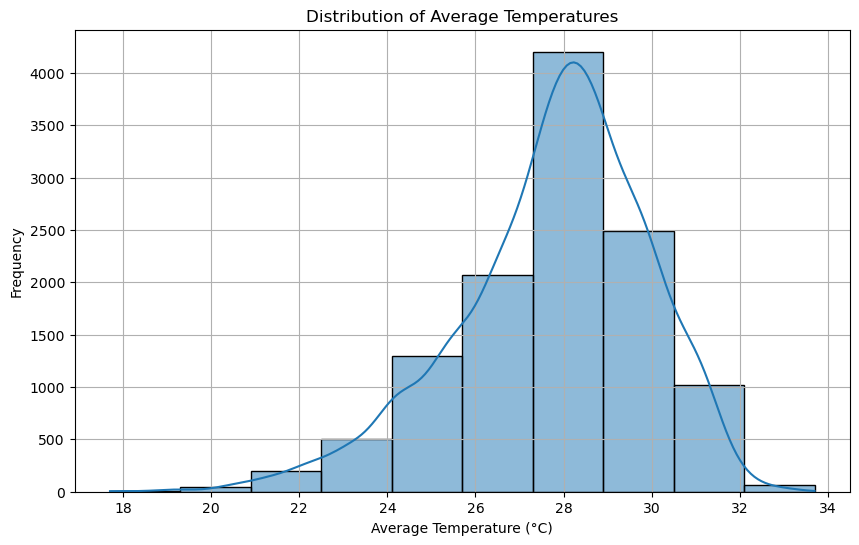

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# Histogram of yearly average temperatures
plt.figure(figsize=(10,6))

sns.histplot(
    df['tavg'],
    bins=10,
    kde=True
)

plt.title('Distribution of Average Temperatures')
plt.xlabel('Average Temperature (°C)')
plt.ylabel('Frequency')

plt.grid(True)
plt.show()